In [1]:
import os

os.environ["TF_ENABLE_ONEDNN_OPTS"]="0"

import numpy as np
import tensorflow as tf
from tabulate import tabulate
from tensorflow.python.client import device_lib
from tqdm import tqdm
import time

2025-10-20 14:57:55.312463: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760952475.367873  349957 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760952475.382312  349957 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760952475.462298  349957 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760952475.462320  349957 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760952475.462321  349957 computation_placer.cc:177] computation placer alr

In [2]:

def print_gpu_details():
    """Prints all available GPUs in a formatted table with key details"""
    # Get list of all devices
    devices = device_lib.list_local_devices()
    gpu_details = []
    
    for device in devices:
        if device.device_type == 'GPU':
            # Extract details from the device description string
            desc = device.physical_device_desc
            details = {
                'Device ID': device.name.split(':')[-1],
                'Name': desc.split('name: ')[1].split(',')[0] if 'name: ' in desc else 'Unknown',
                'Memory (GB)': f"{device.memory_limit / (1024**3):.2f}",
                'PCI Bus ID': desc.split('pci bus id: ')[1].split(',')[0] if 'pci bus id: ' in desc else 'Unknown',
                'GFX Version': os.environ.get('HSA_OVERRIDE_GFX_VERSION', 'Native')
            }
            gpu_details.append(details)
    
    # Print table if GPUs found
    if gpu_details:
        print("\n" + "="*85)
        print("ACTIVE GPU CONFIGURATION".center(85))
        print("="*85)
        print(tabulate(gpu_details, headers="keys", tablefmt="grid"))
        print("="*85+ "\n")
    else:
        print("No GPU devices found!")


def configure_gpu(vram_limit):
    """Configure GPU settings with optional GFX override"""
    
    # Verify GPU availability
    gpus = tf.config.list_physical_devices('GPU')
    
    if gpus:
        try:
            # Limit VRAM on the specified GPU
            
            for gid in range(len(gpus)):
                
                tf.config.experimental.set_virtual_device_configuration(
                    gpus[gid],
                    [tf.config.experimental.VirtualDeviceConfiguration(
                        memory_limit=vram_limit[gid] * 1024)]  # Convert GB to MB
                )
                print(f"GPU {gid} VRAM limited to {vram_limit[gid]}GB")
                
        except RuntimeError as e:
            print(f"Error setting VRAM limit: {e}")
    
    if not gpus:
        raise RuntimeError(f"No GPU found")
    
    for gid in range(len(gpus)):
        print(f"Configured GPU {gid}: {tf.config.experimental.get_device_details(gpus[gid])}") 
        
        with tf.device('/GPU:'+str(gid)):  # Force GPU usage
            x = tf.ones((1, 1))    # Smallest possible tensor
            y = x + 1              # Simple operation
            y.numpy()              # Force execution

In [3]:
VRAM = [3.0]

configure_gpu(VRAM)

print_gpu_details()

GPU 0 VRAM limited to 3.0GB
Configured GPU 0: {'compute_capability': (8, 6), 'device_name': 'NVIDIA GeForce RTX 3050 Laptop GPU'}

                               ACTIVE GPU CONFIGURATION                              
+-------------+------------------------------------+---------------+--------------+---------------+
|   Device ID | Name                               |   Memory (GB) | PCI Bus ID   | GFX Version   |
+=============+====================================+===============+==============+===============+
|           0 | NVIDIA GeForce RTX 3050 Laptop GPU |             3 | 0000:01:00.0 | Native        |
+-------------+------------------------------------+---------------+--------------+---------------+



I0000 00:00:1760952480.725051  349957 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3072 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
I0000 00:00:1760952480.781225  349957 gpu_device.cc:2019] Created device /device:GPU:0 with 3072 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models # type: ignore
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence # type: ignore
from tensorflow.keras.callbacks import ModelCheckpoint # type: ignore

# -------------------------
# Constants
# -------------------------

target = 100000
patch_shape = (50, 50)

Dmax = 800     # max disparity (width of right strip = n + Dmax)
BATCH_SIZE = 128


In [5]:

org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/"
dataset_org_path = "/mnt/Extra/Project_Storage/stereo_ML_dataset/test/"

# -------------------------
# Load memmap datasets
# -------------------------
left_patch_memmap = dataset_org_path + "left_patch.dat"
right_strip_memmap = dataset_org_path + "right_strip.dat"
patch_disparity_memmap = dataset_org_path + "patch_disp.dat"

model_location = org_path+"model/"

left_patches  = np.memmap(left_patch_memmap, dtype=np.uint8, mode='r', shape=(target, patch_shape[0], patch_shape[1]))
right_strips  = np.memmap(right_strip_memmap, dtype=np.uint8, mode='r', shape=(target, patch_shape[0], patch_shape[1] + Dmax))
median_disp   = np.memmap(patch_disparity_memmap, dtype=np.int16, mode='r', shape=(target,))





In [6]:
from tensorflow.keras.utils import Sequence
import numpy as np
from sklearn.model_selection import train_test_split

# -------------------------
# Memmap data generator (uses patch_shape)
# -------------------------
class MemmapGenerator(Sequence):
    def __init__(self, left_mm, right_mm, disp_mm, indices,
                 batch_size=8, patch_shape=(0, 0), Dmax=800):
        self.left_mm = left_mm
        self.right_mm = right_mm
        self.disp_mm = disp_mm
        self.indices = indices
        self.batch_size = batch_size
        self.patch_shape = patch_shape
        self.Dmax = Dmax

    def __len__(self):
        return len(self.indices) // self.batch_size

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        left_batch = self.left_mm[batch_idx]
        right_batch = self.right_mm[batch_idx]
        disp_batch = self.disp_mm[batch_idx].astype('float32') / self.Dmax

        h, w = self.patch_shape
        Xl = np.expand_dims(left_batch[:, :h, :w], axis=-1) / 255.0
        Xr = np.expand_dims(right_batch[:, :h, :w + self.Dmax], axis=-1) / 255.0

        return (Xl.astype('float32'), Xr.astype('float32')), disp_batch


# -------------------------
# Create training and validation generators
# -------------------------
# Use the full dataset
idx_test = np.arange(target)

test_gen = MemmapGenerator(
    left_patches, right_strips, median_disp,
    idx_test, batch_size=BATCH_SIZE,
    patch_shape=patch_shape, Dmax=Dmax
)


Loaded model from /mnt/Extra/Project_Storage/stereo_ML_dataset/model/model_epoch_100.keras
dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])


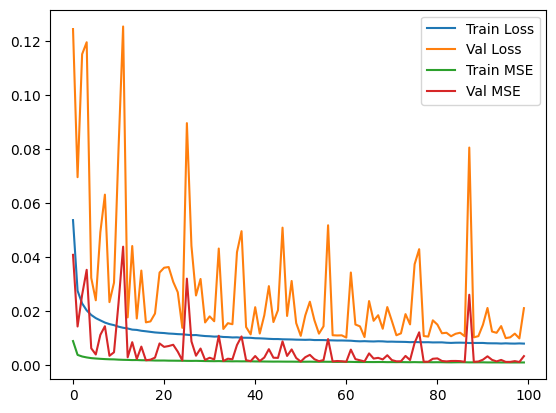

In [7]:
# -------------------------
# LOAD TRAINED MODEL
# -------------------------
model_path = model_location+"model_epoch_100.keras"  # or model_final.keras
model = tf.keras.models.load_model(model_path)
print(f"Loaded model from {model_path}")

# model.summary()

# Load
loaded_history = np.load(model_location+"history.npy",allow_pickle=True).item()
print(loaded_history.keys())   # e.g. dict_keys(['loss', 'mse', 'val_loss', 'val_mse'])

import matplotlib.pyplot as plt

plt.plot(loaded_history['loss'], label='Train Loss')
plt.plot(loaded_history['val_loss'], label='Val Loss')
plt.plot(loaded_history['mse'], label='Train MSE')
plt.plot(loaded_history['val_mse'], label='Val MSE')
plt.legend()
plt.show()


In [8]:
# -------------------------
# EVALUATE
# -------------------------
test_loss, test_mse = model.evaluate(test_gen, verbose=1)
print(f"Test MAE: {test_loss:.4f} | Test MSE: {test_mse:.4f}")


/mnt/Installation/Virtual_Environments/Python_ML/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1760952482.057366  350058 service.cc:152] XLA service 0x70101c00e220 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760952482.057397  350058 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-10-20 14:58:02.068520: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1760952482.161535  350058 cuda_dnn.cc:529] Loaded cuDNN version 90701


  6/781 ━━━━━━━━━━━━━━━━━━━━ 18s 24ms/step - loss: 0.0237 - mse: 0.0041

I0000 00:00:1760952484.882559  350058 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


781/781 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - loss: 0.0214 - mse: 0.0034
Test MAE: 0.0214 | Test MSE: 0.0034


In [9]:
# -------------------------
# PREDICT
# -------------------------

preds = model.predict(test_gen, steps=1000).flatten() * Dmax
print("Predicted disparities (first 5):", preds[:5])
print("Predicted disparities (first 5):", median_disp[:5])

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 18ms/step
Predicted disparities (first 5): [243.10442 253.42958 548.0627  258.10596 299.74164]
Predicted disparities (first 5): [252 261 550 265 301]


/mnt/Installation/Virtual_Environments/Python_ML/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()
